# 04 · La nota del primer agente

**Qué pregunta responde este cuaderno.** ¿Cuántas preguntas acierta el agente de partida y, sobre todo, en qué falla exactamente?

Corregir 20 respuestas a mano no escala, así que se corrigen con tres jueces automáticos: uno comprueba que la frase citada **existe de verdad** en el informe y respalda lo que se afirma, otro que la **cifra coincide** con la que publicó la empresa y el tercero que el agente **usó la herramienta que tocaba**. Acertar por el camino equivocado cuenta como fallo: un número correcto leído de un párrafo es suerte, no método.

El resultado es el **baseline**, la foto congelada de antes de mejorar nada. Sin ella no se puede demostrar después que una mejora mejore algo.

**Entradas:** `golden/golden_propio.jsonl` · **Salidas:** `resultados/baseline/` · Con `EJECUTAR = False` no se llama a ninguna API: se lee lo que ya está guardado en disco.

In [1]:
# Arranque (igual en todos los notebooks): localiza la raíz del repo y hace importable src/
import sys, pathlib, json, importlib
RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(RAIZ / "src"))

import pandas as pd
from IPython.display import display

from agente10k import config, datos, evaluacion

golden = evaluacion.cargar_golden(config.GOLDEN / "golden_propio.jsonl")
huecos = evaluacion.cargar_golden(config.GOLDEN / "golden_huecos.jsonl")
config.RESULTADOS.mkdir(parents=True, exist_ok=True)

print(f"{len(golden)} preguntas · {len(huecos)} huecos")
print(f"modelo: {config.MODELO_ID} · temperatura: {config.TEMPERATURA}")
print("resultados en:", config.RESULTADOS)

20 preguntas · 6 huecos
modelo: openrouter:inclusionai/ling-3.0-flash-fin:free · temperatura: 0
resultados en: C:\Users\Usuario\Downloads\10k-financial-agent\resultados


In [2]:
# Parámetros
EJECUTAR = False
ETIQUETA = "baseline"
# docs/01 §4 fija gemini-3.8-flash, pero la clave del grupo no tiene crédito para
# modelos de pago (Spend 0, "Key limit exceeded"). Se evalúa con el principal de
# la cascada del notebook 02, que cumplió el contrato al 100 % en el banco.
MODELO = "openrouter:inclusionai/ling-3.0-flash-fin:free"
ESTRICTO = True

if EJECUTAR:
    assert config.cargar_clave(), "Falta OPENROUTER_API_KEY: copia .env.example a .env y rellénala"
print(f"EJECUTAR={EJECUTAR} · etiqueta={ETIQUETA} · modelo={MODELO} · estricto={ESTRICTO}")

EJECUTAR=False · etiqueta=baseline · modelo=openrouter:inclusionai/ling-3.0-flash-fin:free · estricto=True


## 0. Andamiaje: hablar todos el mismo idioma

Antes de los jueces, dos piezas de apoyo. `normalizacion.py` decide cuándo dos textos o dos cifras se consideran iguales, con **una sola definición** de cada regla: el guardrail del cuaderno 06 usará exactamente la misma que el juez de cifras, para que no puedan contradecirse. `datos.py` añade tres accesos rápidos a la verdad: el valor publicado, el texto de una sección y el de un fragmento.

## 1. Juez (b): ¿la cifra coincide con lo que publicó la empresa?

La verdad sale del fichero de cifras oficiales, no del texto que devolvió la herramienta: se comprueba el resultado, no el camino.

**Tolerancia documentada** (va al informe): en dólares se admite un 0,5 % de diferencia, porque nadie redondea dos ejercicios hasta confundirlos; en beneficio por acción la tolerancia es absoluta, 0,005, porque el básico y el diluido se parecen demasiado. Si la pregunta es un hueco, acierta quien no da ninguna cifra.

La celda de abajo somete al juez a once casos preparados a mano, incluido el clásico de responder «391.035» cuando lo correcto es «391.035 millones».

In [3]:
from agente10k import evaluadores, normalizacion
importlib.reload(normalizacion); importlib.reload(evaluadores)

p_num = next(p for p in golden if p["familia"] == "numerica")
p_ext = next(p for p in golden if p["familia"] == "extractiva")
p_eps = next(p for p in golden if p.get("unidad") == "USD/shares")
exacta = float(p_num["cifra_esperada"])
eps = float(p_eps["cifra_esperada"])

casos = [
    ("exacta",                 {"cifra": exacta, "unidad": "USD"},                  p_num,     True),
    ("redondeada 0,3 %",       {"cifra": exacta * 1.003, "unidad": "USD"},          p_num,     True),
    ("desviada 2 %",           {"cifra": exacta * 1.02, "unidad": "USD"},           p_num,     False),
    ("en millones, declarado", {"cifra": exacta / 1e6, "unidad": "millones de USD"},p_num,     True),
    ("en millones, sin decir", {"cifra": exacta / 1e6, "unidad": "USD"},            p_num,     False),
    ("sin cifra",              {"cifra": None, "unidad": None},                     p_num,     False),
    ("extractiva: no aplica",  {"cifra": None, "unidad": None},                     p_ext,     None),
    ("BPA exacto",             {"cifra": eps, "unidad": "USD/shares"},              p_eps,     True),
    ("BPA a 0,03",             {"cifra": eps + 0.03, "unidad": "USD/shares"},       p_eps,     False),
    ("hueco: se abstiene",     {"cifra": None, "unidad": None},                     huecos[0], True),
    ("hueco: se lo inventa",   {"cifra": 12345.0, "unidad": "USD"},                 huecos[0], False),
]

for nombre, resp, p, esperado in casos:
    r = evaluadores.evaluar_cifra(resp, p)
    ok = r["b"] is esperado
    print(f"{'ok ' if ok else 'MAL'} {nombre:24s} b={str(r['b']):5s} motivo={r.get('b_motivo')}")
    assert ok, nombre
print("\nevaluar_cifra pasa los 11 casos.")

ok  exacta                   b=True  motivo=ok
ok  redondeada 0,3 %         b=True  motivo=ok
ok  desviada 2 %             b=False motivo=fuera_de_tolerancia
ok  en millones, declarado   b=True  motivo=ok
ok  en millones, sin decir   b=False motivo=error_escala 1e6
ok  sin cifra                b=False motivo=sin_cifra
ok  extractiva: no aplica    b=None  motivo=sin_verdad
ok  BPA exacto               b=True  motivo=ok
ok  BPA a 0,03               b=False motivo=fuera_de_tolerancia
ok  hueco: se abstiene       b=True  motivo=hueco
ok  hueco: se lo inventa     b=False motivo=hueco

evaluar_cifra pasa los 11 casos.


**Qué nos dice esto:** el juez de cifras tolera el redondeo razonable pero no el cambio de escala ni el silencio. Responder «391.035» sin decir «millones» es un fallo, igual que no responder.

## 2. Juez (c): ¿usó la herramienta que tocaba?

Acertar por el camino equivocado es fallo. Una cifra correcta leída de la prosa aprueba el juez (b) pero suspende el (c), y la pregunta se da por fallada.

Cuatro reglas: tienen que aparecer **todas** las herramientas esperadas, no una cualquiera; preguntar por la cobertura del corpus no penaliza ni obliga; las llamadas repetidas cuentan; y además se miran los **argumentos** de la consulta de cifras. Esto último importa más de lo que parece: la caja de Meta en FY2024 y su gasto en I+D se diferencian en un 0,04 %, así que ninguna tolerancia numérica los distingue. Solo los distingue mirar qué pidió el agente.

In [4]:
importlib.reload(evaluadores)

p_comp = next(p for p in golden if p["familia"] == "comparativa")
print(f"{p_num['id']} espera {p_num['herramienta_esperada']}")
print(f"{p_comp['id']} espera {p_comp['herramienta_esperada']} "
      f"(FY {p_comp.get('fiscal_year_base')} y {p_comp['fiscal_year']})\n")

def tc(*llamadas):
    """('get_xbrl_fact', {...}), ('search_filings', {}) -> lista de tool_calls."""
    return [{"name": n, "args": a, "id": f"c{i}"} for i, (n, a) in enumerate(llamadas)]

xb = lambda p, fy=None, con=None: ("get_xbrl_fact", {
    "ticker": p["ticker"], "fiscal_year": fy or p["fiscal_year"],
    "concept": con or p["concept_xbrl"]})

casos = [
    ("numérica: ruta y args ok",
     tc(xb(p_num)), p_num, {"fuente": "xbrl"}, True),
    ("numérica: concepto equivocado",
     tc(xb(p_num, con="StockholdersEquity")), p_num, {"fuente": "xbrl"}, False),
    ("numérica: ejercicio equivocado",
     tc(xb(p_num, fy=2024 if p_num["fiscal_year"] == 2025 else 2025)),
     p_num, {"fuente": "xbrl"}, False),
    ("numérica: camino equivocado",
     tc(("search_filings", {})), p_num, {"fuente": "texto"}, False),
    ("numérica: sin herramientas",
     tc(), p_num, {"fuente": "ninguna"}, False),
    ("comparativa: los dos años",
     tc(xb(p_comp), xb(p_comp, fy=p_comp["fiscal_year_base"]), ("search_filings", {})),
     p_comp, {"fuente": "ambas"}, True),
    ("comparativa: solo un año",
     tc(xb(p_comp), ("search_filings", {})), p_comp, {"fuente": "ambas"}, False),
    ("comparativa: falta el texto",
     tc(xb(p_comp), xb(p_comp, fy=p_comp["fiscal_year_base"])),
     p_comp, {"fuente": "xbrl"}, False),
]

for nombre, llamadas, p, resp, esperado in casos:
    r = evaluadores.evaluar_trayectoria(llamadas, p, resp)
    ok = r["c"] is esperado
    print(f"{'ok ' if ok else 'MAL'} {nombre:32s} c={str(r['c']):5s} "
          f"args={str(r['c_args_ok']):5s} usadas={r['c_usadas']}")
    assert ok, nombre
print("\nevaluar_trayectoria pasa los 8 casos.")

g3-001 espera ['get_xbrl_fact']
g3-014 espera ['get_xbrl_fact', 'search_filings'] (FY 2024 y 2025)

ok  numérica: ruta y args ok         c=True  args=True  usadas=['get_xbrl_fact']
ok  numérica: concepto equivocado    c=False args=False usadas=['get_xbrl_fact']
ok  numérica: ejercicio equivocado   c=False args=False usadas=['get_xbrl_fact']
ok  numérica: camino equivocado      c=False args=False usadas=['search_filings']
ok  numérica: sin herramientas       c=False args=False usadas=[]
ok  comparativa: los dos años        c=True  args=True  usadas=['get_xbrl_fact', 'search_filings']
ok  comparativa: solo un año         c=False args=False usadas=['get_xbrl_fact', 'search_filings']
ok  comparativa: falta el texto      c=False args=True  usadas=['get_xbrl_fact']

evaluar_trayectoria pasa los 8 casos.


**Qué nos dice esto:** sin mirar los argumentos de la consulta, dos magnitudes casi idénticas de la misma empresa serían indistinguibles. La trayectoria es lo que convierte una coincidencia numérica en una respuesta trazable.

## 3. Juez (a): ¿la cita existe y respalda lo que se afirma?

Dos comprobaciones mecánicas y una de fondo. **Existe**: la frase aparece literalmente en alguna sección del corpus. **Vista**: la frase aparece entre lo que las herramientas devolvieron en esa misma ejecución. **Respalda**: un modelo juez revisa frase a frase si la cita sostiene lo que la respuesta afirma.

«Vista» es la que caza al modelo que cita de memoria: una frase que está en el corpus pero que el agente nunca recuperó no es evidencia, es recuerdo.

In [5]:
importlib.reload(evaluadores)

p_ext = next(p for p in golden if p["familia"] == "extractiva" and p.get("chunk_id_esperado"))
ancla = p_ext["ancla_texto"]
cid = p_ext["chunk_id_esperado"]
texto_visto = datos.texto_chunk(cid)

def obs(*textos):
    return [{"name": "search_filings", "tool_call_id": f"c{i}", "content": t}
            for i, t in enumerate(textos)]

base = {"ticker": p_ext["ticker"], "ejercicio": p_ext["fiscal_year"], "chunk_id": cid}

casos = [
    ("cita literal y vista",
     {**base, "cita": ancla}, obs(texto_visto), (True, True)),
    ("cita con elisión",
     {**base, "cita": f"{ancla[:40]} [...] {ancla[-40:]}"}, obs(texto_visto), (True, True)),
    ("existe pero NO la vio",
     {**base, "cita": ancla}, [], (True, False)),
    ("cita inventada",
     {**base, "cita": "The company will definitely double its revenue next year."},
     obs(texto_visto), (False, False)),
    ("sin cita",
     {**base, "cita": None}, obs(texto_visto), (False, False)),
]

for nombre, resp, observaciones, (exp_existe, exp_vista) in casos:
    r = evaluadores.etapa1_cita(resp, p_ext, observaciones)
    ok = (r["a_existe"], r["a_vista"]) == (exp_existe, exp_vista)
    print(f"{'ok ' if ok else 'MAL'} {nombre:24s} existe={str(r['a_existe']):5s} "
          f"vista={str(r['a_vista']):5s} chunk_ok={str(r.get('a_chunk_id_ok')):5s}"
          + (f" cobertura={r['a_cobertura']}" if "a_cobertura" in r else ""))
    assert ok, nombre
print("\netapa1_cita pasa los 5 casos.")

ok  cita literal y vista     existe=True  vista=True  chunk_ok=True 
ok  cita con elisión         existe=True  vista=True  chunk_ok=True 
ok  existe pero NO la vio    existe=True  vista=False chunk_ok=True 


ok  cita inventada           existe=False vista=False chunk_ok=False cobertura=0.0
ok  sin cita                 existe=False vista=False chunk_ok=None 

etapa1_cita pasa los 5 casos.


**Qué nos dice esto:** una cita solo vale si el agente la recuperó en esa misma ejecución. Así no cuela una frase correcta sacada de la memoria del modelo en lugar del informe.

## 4. Qué significa acertar en cada familia

Una pregunta se da por acertada solo si pasa todo lo que le corresponde:

- **Numérica:** la cifra coincide **y** se pidió a la fuente autorizada.
- **Extractiva:** la cita existe, se vio, respalda lo afirmado **y** se usó la búsqueda.
- **Comparativa:** todo lo anterior **y** las dos cifras correctas.
- **Hueco:** se abstiene, no da cifra, no estima por detrás **y** consultó antes de abstenerse.

Además se marca la **abstención indebida**: decir «no hay dato» cuando sí lo había. Es el error contrario y también cuenta como fallo.

In [6]:
importlib.reload(evaluadores)

def fila(p, resp, llamadas=(), observaciones=()):
    return {"id": p["id"], "golden": p, "respuesta": resp,
            "tool_calls": list(llamadas), "observaciones": list(observaciones)}

xbrl_ok = [{"name": "get_xbrl_fact", "id": "c0", "args": {
    "ticker": p_num["ticker"], "fiscal_year": p_num["fiscal_year"],
    "concept": p_num["concept_xbrl"]}}]

# numérica perfecta
s1 = evaluadores.puntuar_fila(fila(
    p_num, {"cifra": float(p_num["cifra_esperada"]), "unidad": "USD", "fuente": "xbrl"},
    xbrl_ok))
print(f"numérica ok            acierto={s1['acierto']}  b={s1['b']} c={s1['c']}")

# numérica correcta por el camino equivocado
s2 = evaluadores.puntuar_fila(fila(
    p_num, {"cifra": float(p_num["cifra_esperada"]), "unidad": "USD", "fuente": "texto"},
    [{"name": "search_filings", "id": "c0", "args": {}}]))
print(f"camino equivocado      acierto={s2['acierto']}  b={s2['b']} c={s2['c']}")

# hueco: se abstiene
h = huecos[0]
s3 = evaluadores.puntuar_fila(fila(
    h, {"cifra": None, "fuente": "ninguna"},
    [{"name": "get_xbrl_fact", "id": "c0", "args": {
        "ticker": h["ticker"], "fiscal_year": h["fiscal_year"], "concept": h["concept_xbrl"]}}]))
print(f"hueco: se abstiene     acierto={s3['acierto']}  abstiene={s3['abstiene']}")

# abstención indebida: dice "ninguna" en una pregunta que sí tiene dato
s4 = evaluadores.puntuar_fila(fila(
    p_num, {"cifra": None, "fuente": "ninguna"}, xbrl_ok))
print(f"abstención indebida    acierto={s4['acierto']}  indebida={s4['abstencion_indebida']}")

# extractiva sin juez: estricto frente a provisional
f_ext = fila(p_ext, {**base, "cita": ancla, "respuesta": "x", "fuente": "texto"},
             [{"name": "search_filings", "id": "c0", "args": {}}], obs(texto_visto))
print(f"extractiva estricta    acierto={evaluadores.puntuar_fila(f_ext)['acierto']}")
print(f"extractiva provisional acierto={evaluadores.puntuar_fila(f_ext, estricto=False)['acierto']}")

assert s1["acierto"] is True and s2["acierto"] is False
assert s3["acierto"] is True and s4["abstencion_indebida"] is True
print("\npuntuar_fila y acierto funcionan.")

numérica ok            acierto=True  b=True c=True
camino equivocado      acierto=False  b=True c=False
hueco: se abstiene     acierto=True  abstiene=True
abstención indebida    acierto=False  indebida=True
extractiva estricta    acierto=None


extractiva provisional acierto=True

puntuar_fila y acierto funcionan.


**Qué nos dice esto:** la regla de acierto es exigente a propósito. Un agente que acierta la cifra copiándola de un párrafo suspende, porque ese camino no generaliza: la próxima tabla partida le dará el año equivocado.

## 5. Ejecutar las 20 preguntas

Ejecutar y puntuar están separados a propósito: lo primero llama al modelo y guarda sus respuestas en bruto; lo segundo aplica los jueces sin gastar nada. Así, cambiar un umbral o añadir un juez no obliga a volver a pagar las 20 preguntas.

Con `EJECUTAR = False` estas celdas no hacen nada: reutilizan lo guardado.

In [7]:
if EJECUTAR:
    import time
    t0 = time.perf_counter()
    evaluadores.ejecutar_golden(config.GOLDEN / "golden_propio.jsonl",
                                etiqueta="sonda", sistema="baseline",
                                modelo=MODELO, limite=3)
    t = time.perf_counter() - t0
    print(f"\n3 preguntas en {t:.0f}s → las 20 tardarían ~{t/3*20/60:.1f} min")

In [8]:
predicciones = config.RESULTADOS / ETIQUETA / "predicciones.jsonl"

def _utiles(ruta):
    """True si el fichero existe y no son todo errores."""
    if not ruta.is_file():
        return False
    filas = [json.loads(x) for x in ruta.read_text(encoding="utf-8").splitlines() if x.strip()]
    return bool(filas) and not all(f.get("error") for f in filas)

if _utiles(predicciones):
    print(f"Reutilizando {predicciones} (no se llama al modelo).")
elif EJECUTAR:
    print(f"Ejecutando {len(golden)} preguntas con {MODELO}...\n")
    evaluadores.ejecutar_golden(config.GOLDEN / "golden_propio.jsonl",
                                etiqueta=ETIQUETA, sistema="baseline", modelo=MODELO)
else:
    print("Sin predicciones útiles y EJECUTAR=False.")

Reutilizando C:\Users\Usuario\Downloads\10k-financial-agent\resultados\baseline\predicciones.jsonl (no se llama al modelo).


In [9]:
huecos_pred = config.RESULTADOS / f"{ETIQUETA}_huecos" / "predicciones.jsonl"

if huecos_pred.is_file():
    print("Huecos ya ejecutados.")
elif EJECUTAR:
    evaluadores.ejecutar_golden(config.GOLDEN / "golden_huecos.jsonl",
                                etiqueta=f"{ETIQUETA}_huecos", sistema="baseline", modelo=MODELO)

Huecos ya ejecutados.


## 6. Resultados del baseline

Todo lo que sigue se lee de disco, sin volver a ejecutar nada. La tabla detalla pregunta a pregunta qué juez aprobó y cuál no, junto con el tiempo y el número de llamadas a herramienta que costó cada una.

In [10]:
# repuntuar() (no puntuar()) a propósito: NO escribe en resultados/<etiqueta>/, así que
# nunca sobrescribe el baseline congelado aunque el código de los evaluadores cambie después
# (regla 6 de CLAUDE.md). Muestra la nota vigente sin tocar el artefacto guardado en disco.
if predicciones.is_file():
    tabla, _ = evaluadores.repuntuar(ETIQUETA, estricto=ESTRICTO)
    display(tabla[["id", "familia", "b", "c", "a", "acierto",
                   "b_motivo", "latencia_s", "n_llamadas", "usd"]])

if huecos_pred.is_file():
    print("\n--- HUECOS ---")
    tabla_h, _ = evaluadores.repuntuar(f"{ETIQUETA}_huecos", estricto=ESTRICTO)
    display(tabla_h[["id", "familia", "abstiene", "sin_cifra", "c", "acierto"]])

,id,familia,b,c,a,acierto,b_motivo,latencia_s,n_llamadas,usd
0,g3-001,numerica,True,True,None,True,ok,2.844321,1,None
1,g3-002,numerica,True,True,None,True,ok,3.864141,1,None
2,g3-003,numerica,True,True,None,True,ok,2.395955,1,None
3,g3-004,numerica,True,True,None,True,ok,3.153364,1,None
4,g3-005,numerica,True,True,None,True,ok,2.814315,1,None
5,g3-006,numerica,True,True,None,True,ok,3.111282,1,None
6,g3-007,numerica,True,True,None,True,ok,3.239423,1,None
7,g3-008,extractiva,None,True,None,None,sin_verdad,16.997372,2,None
8,g3-009,extractiva,None,True,None,None,sin_verdad,9.970589,3,None
9,g3-010,extractiva,None,True,None,None,sin_verdad,10.198774,4,None



--- HUECOS ---


,id,familia,abstiene,sin_cifra,c,acierto
0,g3-h001,hueco,False,False,True,False
1,g3-h002,hueco,False,False,True,False
2,g3-h003,hueco,True,True,True,True
3,g3-h004,hueco,False,False,True,False
4,g3-h005,hueco,True,True,True,False
5,g3-h006,hueco,True,True,True,True


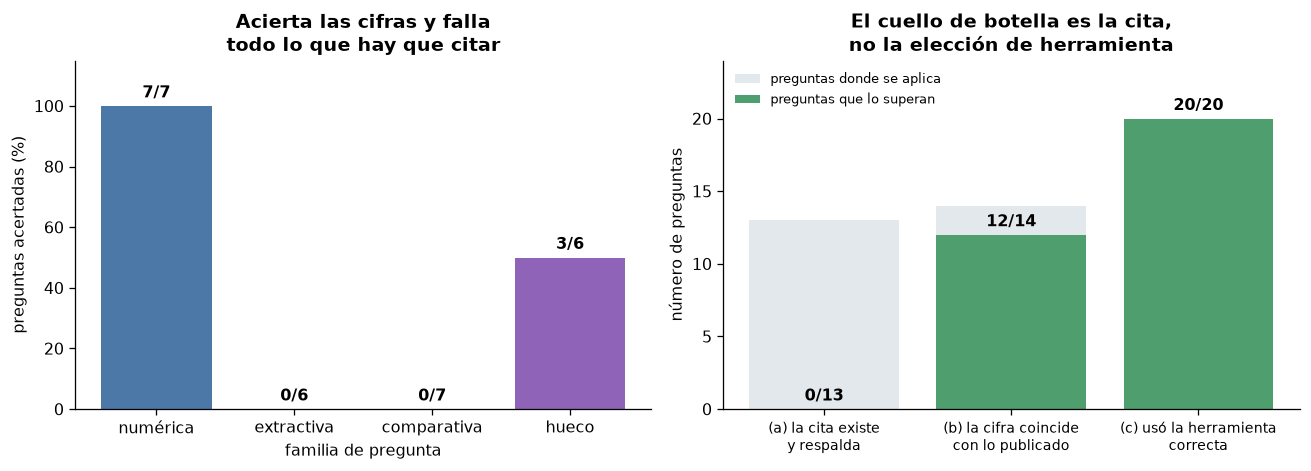

Respuestas que dejaron vacío el campo 'cita': 20 de 20.
Latencia media: 9.8 s por pregunta · llamadas a herramienta por pregunta: 3.3 · modelo: inclusionai/ling-3.0-flash-fin:free


In [11]:
# Dos gráficos leídos de resultados/baseline*/ ya guardados.
# Funciona con EJECUTAR=False: no llama a la API y no escribe nada en resultados/.
import matplotlib.pyplot as plt

COLOR_FAMILIA = {"numerica": "#4C78A8", "extractiva": "#59A14F",
                 "comparativa": "#F28E2B", "hueco": "#8F63B8"}
plt.rcParams.update({"figure.dpi": 115, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})


def _fraccion(kn):
    """'7/7' -> (7, 7) · '—' o ausente -> None"""
    if not isinstance(kn, str) or "/" not in kn:
        return None
    k, n = kn.split("/")
    return (int(k), int(n)) if int(n) else None


def _leer_json(ruta):
    return json.loads(ruta.read_text(encoding="utf-8")) if ruta.is_file() else {}


resumen_baseline = _leer_json(config.RESULTADOS / "baseline" / "resumen.json")
resumen_baseline_huecos = _leer_json(config.RESULTADOS / "baseline_huecos" / "resumen.json")
familias_baseline = resumen_baseline.get("familias", {})

fracciones = {
    "numerica": _fraccion(familias_baseline.get("numerica")),
    "extractiva": _fraccion(familias_baseline.get("extractiva")),
    "comparativa": _fraccion(familias_baseline.get("comparativa")),
    "hueco": _fraccion((resumen_baseline_huecos.get("familias") or {}).get("hueco")),
}
NOMBRE_ES = {"numerica": "numérica", "extractiva": "extractiva",
             "comparativa": "comparativa", "hueco": "hueco"}

if any(fracciones.values()):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2))

    claves = list(fracciones)
    tasas = [100 * f[0] / f[1] if f else 0 for f in fracciones.values()]
    barras = ax1.bar(range(len(claves)), tasas, color=[COLOR_FAMILIA[c] for c in claves])
    ax1.bar_label(barras,
                  labels=[f"{f[0]}/{f[1]}" if f else "n/d" for f in fracciones.values()],
                  padding=3, fontweight="bold")
    ax1.set_xticks(range(len(claves)), [NOMBRE_ES[c] for c in claves])
    ax1.set_xlabel("familia de pregunta")
    ax1.set_ylabel("preguntas acertadas (%)")
    ax1.set_ylim(0, 115)
    ax1.set_title("Acierta las cifras y falla\ntodo lo que hay que citar")

    # Por qué falla: los tres jueces por separado, sobre las mismas 20 preguntas
    filas_punt = [json.loads(x) for x in
                  (config.RESULTADOS / "baseline" / "puntuaciones.jsonl")
                  .read_text(encoding="utf-8").splitlines() if x.strip()]
    CRITERIOS = [("a", "(a) la cita existe\ny respalda"),
                 ("b", "(b) la cifra coincide\ncon lo publicado"),
                 ("c", "(c) usó la herramienta\ncorrecta")]
    aplicables, superados = [], []
    for clave, _ in CRITERIOS:
        aplica = [p for p in filas_punt if p.get(clave) is not None]
        aplicables.append(len(aplica))
        superados.append(sum(1 for p in aplica if p[clave] is True))

    xpos = range(len(CRITERIOS))
    ax2.bar(xpos, aplicables, color="#E3E8EC", label="preguntas donde se aplica")
    barras2 = ax2.bar(xpos, superados, color="#4E9F6D", label="preguntas que lo superan")
    ax2.bar_label(barras2, labels=[f"{s}/{a}" for s, a in zip(superados, aplicables)],
                  padding=3, fontweight="bold")
    ax2.set_xticks(list(xpos), [t for _, t in CRITERIOS], fontsize=9)
    ax2.set_ylabel("número de preguntas")
    ax2.set_ylim(0, max(aplicables) + 4)
    ax2.legend(frameon=False, loc="upper left", fontsize=8)
    ax2.set_title("El cuello de botella es la cita,\nno la elección de herramienta")

    plt.tight_layout()
    plt.show()

    sin_cita = sum(1 for p in filas_punt if not p.get("a_cita"))
    print(f"Respuestas que dejaron vacío el campo 'cita': {sin_cita} de {len(filas_punt)}.")
    print(f"Latencia media: {resumen_baseline.get('latencia_media_s', float('nan')):.1f} s por pregunta"
          f" · llamadas a herramienta por pregunta: {resumen_baseline.get('llamadas_medias')}"
          f" · modelo: {resumen_baseline.get('modelo')}")
else:
    print("Sin resumen guardado todavía: ejecuta con EJECUTAR=True o espera a que existan "
          "resultados/baseline*/resumen.json.")

**Qué nos dice esto:** el agente de partida elige bien la herramienta en las 20 preguntas y acierta 12 de las 14 cifras que se le piden, pero **no rellena el campo de la cita en ninguna**: escribe la frase dentro del texto de la respuesta y deja el hueco reservado para la evidencia en blanco. Como todas las preguntas de texto exigen una cita verificable, se pierden enteras.

Ese es el diagnóstico que ordena el trabajo siguiente: no hay que cambiar de modelo ni de herramienta, hay que **obligar al agente a devolver la cita**. De eso se ocupan el retrieval del cuaderno 05 y los guardrails del 06.

## 7. Los dos jueces que sí usan modelo

El resto de comprobaciones son mecánicas; estas dos no. **Respaldo** etiqueta cada frase de la respuesta contra la cita y solo aprueba si todas las que afirman algo quedan sostenidas: una comparativa respaldada a medias suspende. **Corrección** compara la respuesta con la esperada; el formato puede variar, pero la unidad, la escala y el ejercicio no.

Los veredictos se guardan en caché, así que volver a puntuar cuesta cero llamadas. Los fallos no se cachean: un límite de tasa se reintenta solo en lo que falló.

In [12]:
if EJECUTAR and predicciones.is_file():
    juez = evaluadores.crear_juez(MODELO)
    print(f"Juez: {juez.modelo_id} · {len(juez.cache)} veredictos en caché\n")

    tabla = evaluadores.puntuar(ETIQUETA, juez=juez, estricto=True)
    display(tabla[["id", "familia", "a", "a_existe", "a_vista", "a_respalda",
                   "correcta", "b", "c", "acierto"]])

    print(f"\njuez: {juez.llamadas} llamadas, {juez.fallos} fallos")
    if juez.fallos:
        print("Vuelve a ejecutar esta celda: los fallos no se cachean y se reintentan.")

In [13]:
if EJECUTAR and huecos_pred.is_file():
    tabla_h = evaluadores.puntuar(f"{ETIQUETA}_huecos", juez=juez, estricto=True)
    display(tabla_h[["id", "familia", "abstiene", "sin_cifra", "c", "acierto"]])